# Baza- Hybrid Multimodal Anemia Detection System


**Components:**
1. **Tabular Model**
2. **Visual Model**
3. **Late Fusion**



## 1. Imports & Configuration

In [97]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#  Part 1: Tabular Model 

Process CBC blood test data

## 1. Data Loading

In [ ]:

df = pd.read_csv(r"C:\Users\USER\Capstone\Bari\data\Tabular\anemia.csv")
df.head()

print("Dataset Shape:", df.shape)

df.info()

df.describe()

missing = df.isnull().sum()
print(missing)


Dataset Shape: (710, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IMAGE_ID               710 non-null    object 
 1   HB_LEVEL               710 non-null    float64
 2   Severity               710 non-null    object 
 3   Age(Months)            710 non-null    int64  
 4   GENDER                 710 non-null    object 
 5   REMARK                 710 non-null    object 
 6   HOSPITAL               710 non-null    object 
 7   CITY/TOWN              710 non-null    object 
 8   MUNICIPALITY/DISTRICT  710 non-null    object 
 9   REGION                 710 non-null    object 
 10  COUNTRY                710 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 61.1+ KB
IMAGE_ID                 0
HB_LEVEL                 0
Severity                 0
Age(Months)              0
GENDER                 

## 2. Data Cleaning and Preprocessing

In [ ]:
print(df.columns)

Index(['IMAGE_ID', 'HB_LEVEL', 'Severity', 'Age(Months)', 'GENDER', 'REMARK',
       'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY'],
      dtype='object')


In [ ]:
df['Age_Years'] = df['Age(Months)'] / 12

Categorical columns: ['IMAGE_ID', 'Severity', 'GENDER', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']
Encoded categorical columns.


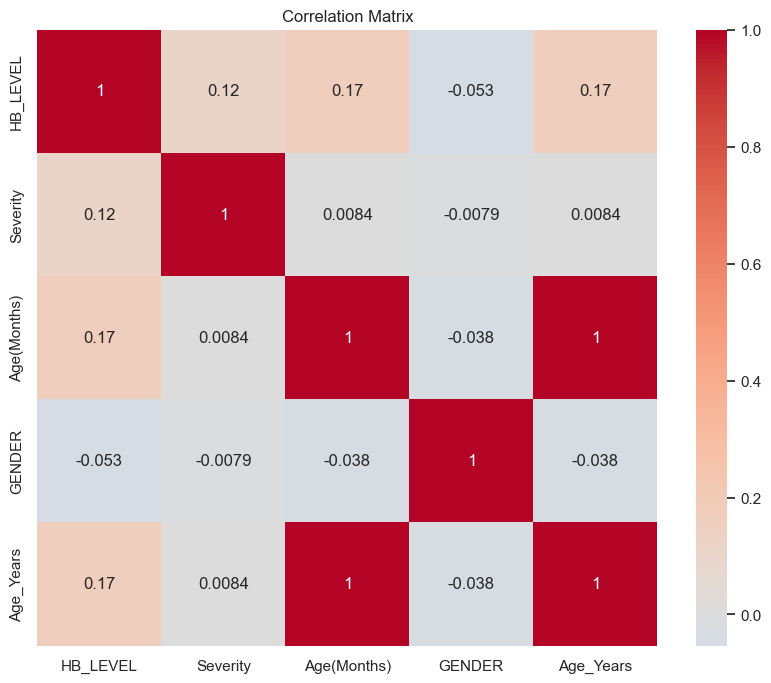

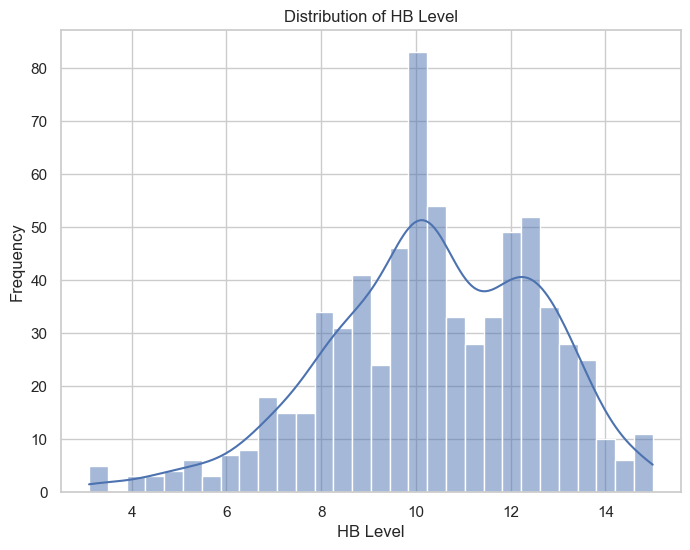

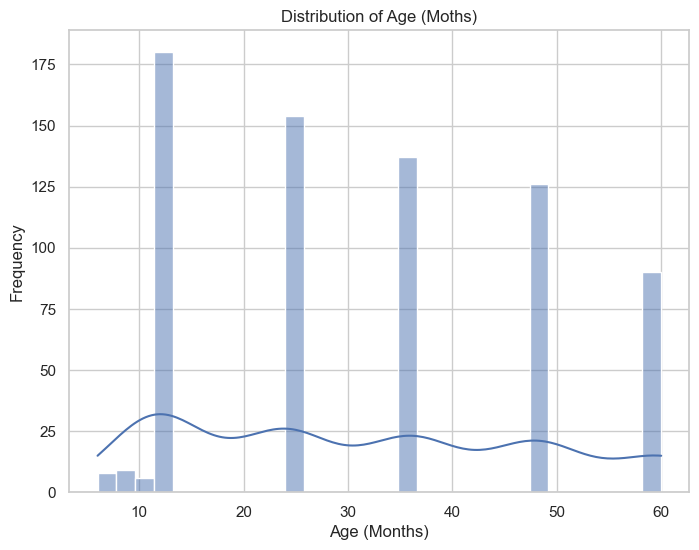


Skewness of HB_LEVEL: -0.4303898205250962
Skewness of Age (Years): 0.27475039611988206


In [101]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Step 2: Identify categorical columns (e.g., GENDER, HOSPITAL, etc.)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Step 3: Encode all categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store if needed later
print("Encoded categorical columns.")

# Step 4: Drop unused columns (e.g., metadata)
columns_to_drop = ['IMAGE_ID', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']  # Adjust as needed
df.drop(columns=columns_to_drop,inplace=True)

# Step 5: Compute correlation matrix
corr_matrix = df.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Step 6: Visualize distributions
# Histogram for HB_LEVEL
plt.figure(figsize=(8, 6))
sns.histplot(df['HB_LEVEL'], kde=True, bins=30)
plt.title('Distribution of HB Level')
plt.xlabel('HB Level')
plt.ylabel('Frequency')
plt.show()

# Histogram for Age
plt.figure(figsize=(8, 6))
sns.histplot(df['Age(Months)'], kde=True, bins=30)
plt.title('Distribution of Age (Moths)')
plt.xlabel('Age (Months)')
plt.ylabel('Frequency')
plt.show()

# Step 7: Check for outliers or skew
# For example, check skewness
print("\nSkewness of HB_LEVEL:", df['HB_LEVEL'].skew())
print("Skewness of Age (Years):", df['Age_Years'].skew())

# Once satisfied, you can proceed with stratified 5-fold cross-validation

In [102]:
def map_severity(row):
    hb = row["HB_LEVEL"]
    age = row["Age_Years"]
    gender = str(row["GENDER"]).strip().lower()

    # Children 6–59 months (0.5–5 years)
    if 0.5 <= age < 5:
        if hb >= 11:
            return "Normal"
        elif 10 <= hb < 11:
            return "Mild"
        elif 7 <= hb < 10:
            return "Moderate"
        else:
            return "Severe"

    # Children 5–11 years
    elif 5 <= age < 12:
        if hb >= 11.5:
            return "Normal"
        elif 11 <= hb < 11.5:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adolescents 12–14 years
    elif 12 <= age < 15:
        if hb >= 12:
            return "Normal"
        elif 11 <= hb < 12:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adult women
    elif age >= 15 and gender == "female":
        if hb >= 12:
            return "Normal"
        elif 11 <= hb < 12:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adult men
    elif age >= 15 and gender == "male":
        if hb >= 13:
            return "Normal"
        elif 11 <= hb < 13:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    return "Unknown"

# Overwrite severity using WHO mapping
df["Severity_WHO"] = df.apply(map_severity, axis=1)

print(df["Severity_WHO"].value_counts())

Severity_WHO
Normal      282
Moderate    242
Mild        132
Severe       54
Name: count, dtype: int64


In [103]:
print("Overall HB statistics:")
print(df["HB_LEVEL"].describe())

Overall HB statistics:
count    710.000000
mean      10.358521
std        2.258663
min        3.100000
25%        8.900000
50%       10.300000
75%       12.100000
max       15.000000
Name: HB_LEVEL, dtype: float64


In [104]:
import numpy as np

# Add a small constant to avoid log(0)
df['HB_LOG'] = np.log(df['HB_LEVEL'] + 1)

# Check the new skewness
print("New skewness of HB_LOG:", df['HB_LOG'].skew())

New skewness of HB_LOG: -1.224896772766387


In [105]:
mean_hb_by_severity = df.groupby("Severity_WHO")["HB_LEVEL"].mean()
print("\nMean HB per Severity:")
print(mean_hb_by_severity)


Mean HB per Severity:
Severity_WHO
Mild        10.363939
Moderate     8.823347
Normal      12.553404
Severe       5.762963
Name: HB_LEVEL, dtype: float64


In [106]:
mean_hb_by_gender = df.groupby("GENDER")["HB_LEVEL"].mean()
print("\nMean HB per Gender:")
print(mean_hb_by_gender)


Mean HB per Gender:
GENDER
0    10.496797
1    10.253787
Name: HB_LEVEL, dtype: float64


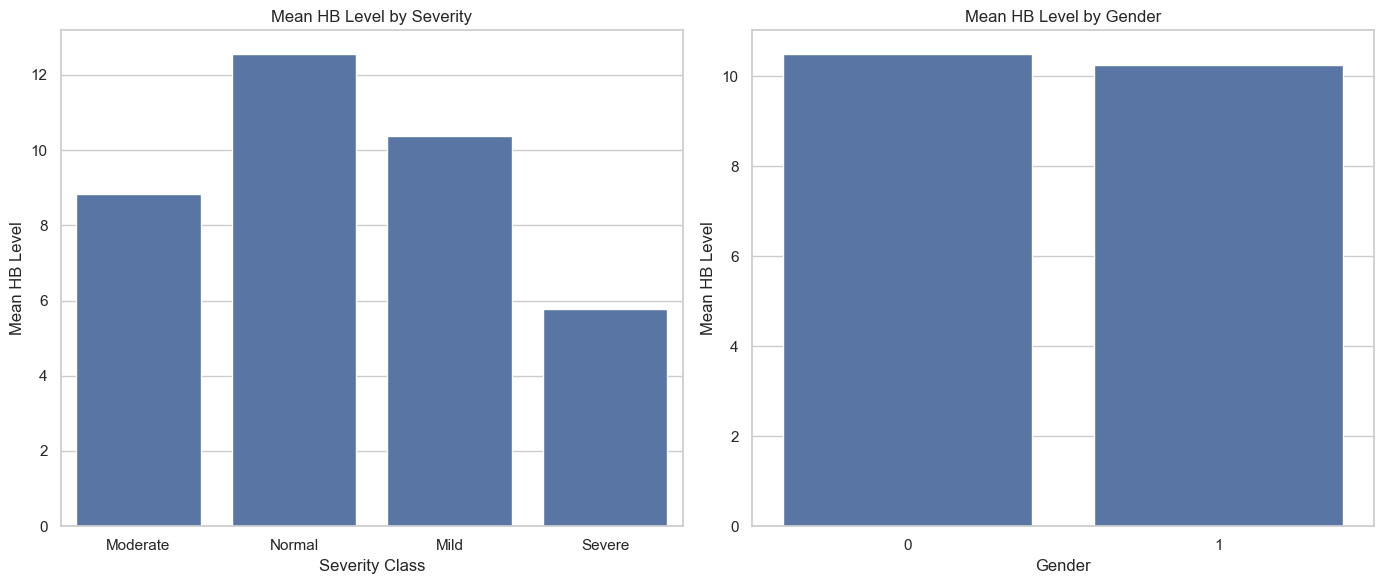

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot mean HB by severity class
sns.barplot(x='Severity_WHO', y='HB_LEVEL', data=df, estimator='mean', errorbar=None, ax=axes[0])
axes[0].set_title('Mean HB Level by Severity')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Mean HB Level')

# Plot mean HB by gender
sns.barplot(x='GENDER', y='HB_LEVEL', data=df, estimator='mean', errorbar=None, ax=axes[1])
axes[1].set_title('Mean HB Level by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Mean HB Level')

plt.tight_layout()
plt.show()

## Data splitting & modelling


In [108]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Fit on the target
y_encoded = le.fit_transform(ml_df[target])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Mild': 0, 'Moderate': 1, 'Normal': 2, 'Severe': 3}


In [109]:
import pandas as pd
import numpy as np

# Features and target
features = ["HB_LEVEL", "Age_Years", "GENDER"]
target = "Severity_WHO"

ml_df = df[features + [target]].copy()

# One-hot encode Gender
ml_df = pd.get_dummies(ml_df, columns=['GENDER'], drop_first=True)

# Split features and target
X = ml_df.drop(columns=[target])
y = y_encoded

2    282
1    242
0    132
3     54
Name: count, dtype: int64


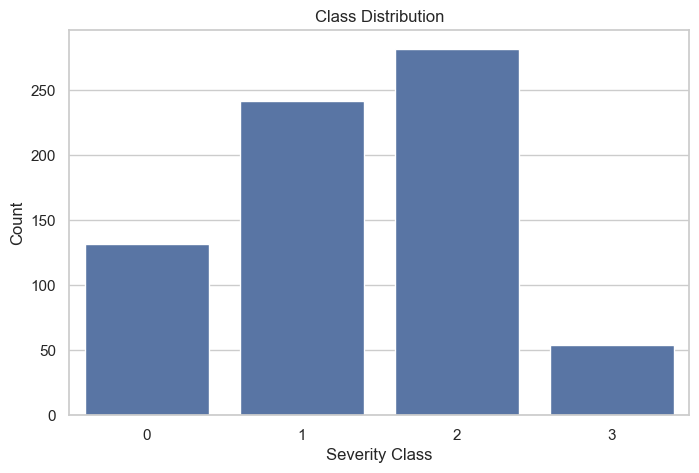

In [110]:
import pandas as pd
# Check class distribution
y_series = pd.Series(y)
class_counts = y_series.value_counts()
print(class_counts)

# Optionally, plot it
import seaborn as sns
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Severity Class')
plt.ylabel('Count')
plt.show()

In [111]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Fit on the target
y_encoded = le.fit_transform(ml_df[target])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Mild': 0, 'Moderate': 1, 'Normal': 2, 'Severe': 3}


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {0: 1.3523809523809525, 1: 0.7319587628865979, 2: 0.6283185840707964, 3: 3.302325581395349}


In [113]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


lr_model = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print(" Logistic Regression")
print(classification_report(y_test, y_pred_lr))

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(" Random Forest")
print(classification_report(y_test, y_pred_rf))

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(" XGBoost ")
print(classification_report(y_test, y_pred_xgb))


# One-hot encode target
y_train_cat = to_categorical(pd.Categorical(y_train, categories=classes).codes)
y_test_cat = to_categorical(pd.Categorical(y_test, categories=classes).codes)

# Map class weights for Keras
class_weights_keras = {i: w for i, w in enumerate(weights)}

# Define model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_keras,
    verbose=1
)

# Evaluate
test_loss, test_acc = nn_model.evaluate(X_test_scaled, y_test_cat)
print("Neural Network ")
print("Test Accuracy:", test_acc)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        27
           1       0.97      0.77      0.86        48
           2       1.00      0.93      0.96        56
           3       0.77      0.91      0.83        11

    accuracy                           0.89       142
   macro avg       0.86      0.90      0.87       142
weighted avg       0.91      0.89      0.89       142

 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [11:46:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        11

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.3062 - loss: 1.3997 - val_accuracy: 0.5000 - val_loss: 1.3220
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4273 - loss: 1.3065 - val_accuracy: 0.5175 - val_loss: 1.2747
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4846 - loss: 1.2505 - val_accuracy: 0.5263 - val_loss: 1.2160
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5198 - loss: 1.1632 - val_accuracy: 0.5175 - val_loss: 1.1598
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5286 - loss: 1.1355 - val_accuracy: 0.5175 - val_loss: 1.0992
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5198 - loss: 1.0928 - val_accuracy: 0.5175 - val_loss: 1.0276
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5308 - loss: 1.0349 - val_accuracy: 0.5175 - val_loss: 0.9613
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5815 - loss: 0.9416 - val_accuracy: 0.5263 - 

Logistic Regression
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        27
           1       0.97      0.77      0.86        48
           2       1.00      0.93      0.96        56
           3       0.77      0.91      0.83        11

    accuracy                           0.89       142
   macro avg       0.86      0.90      0.87       142
weighted avg       0.91      0.89      0.89       142



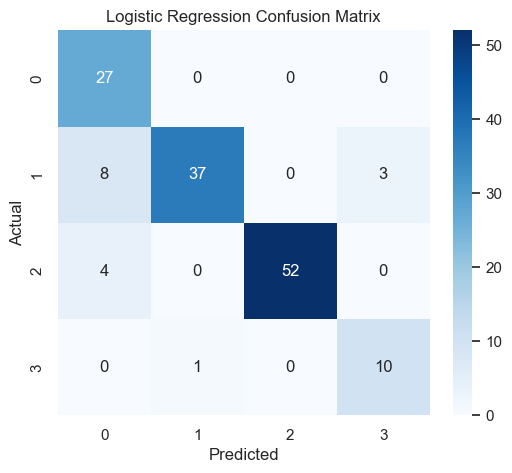

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



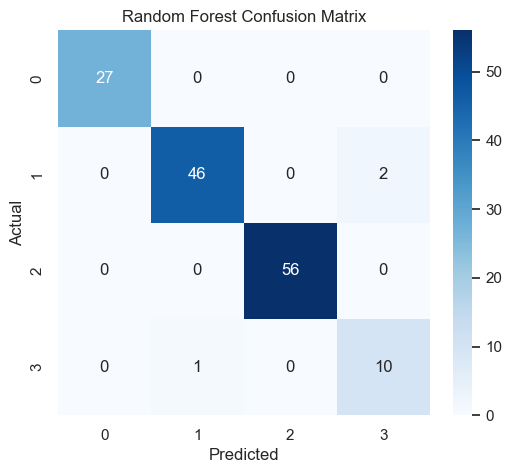

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        11

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



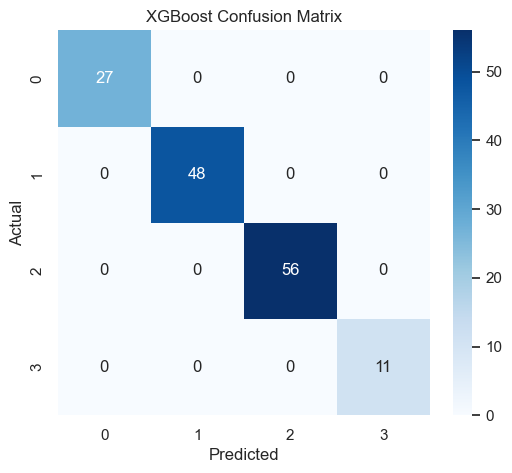

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002543789A5C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Neural Network
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       1.00      0.81      0.90        48
           2       0.95      0.98      0.96        56
           3       0.69      1.00      0.81        11

    accuracy                           0.91       142
   macro avg       0.87      0.92      0.88       142
weighted avg       0.92      0.91      0.91       142



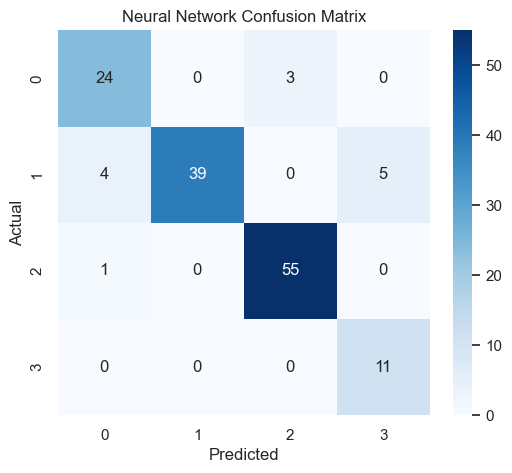


Model Comparison


,Accuracy,Macro F1
Logistic Regression,0.887324,0.868736
Random Forest,0.978873,0.959497
XGBoost,1.000000,1.000000
Neural Network,0.908451,0.883355


In [114]:
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Helper function to plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

# Initialize summary dictionary
summary_results = {}

# Logistic Regression
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")
summary_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Macro F1': classification_report(y_test, y_pred_lr, output_dict=True)['macro avg']['f1-score']
}

# Random Forest
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
summary_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Macro F1': classification_report(y_test, y_pred_rf, output_dict=True)['macro avg']['f1-score']
}

# XGBoost
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")
summary_results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Macro F1': classification_report(y_test, y_pred_xgb, output_dict=True)['macro avg']['f1-score']
}

# Neural Network
# Predict classes from softmax probabilities
y_pred_nn_probs = nn_model.predict(X_test_scaled)
y_pred_nn_classes = classes[np.argmax(y_pred_nn_probs, axis=1)]

print("Neural Network")
print(classification_report(y_test, y_pred_nn_classes))
plot_conf_matrix(y_test, y_pred_nn_classes, "Neural Network Confusion Matrix")
summary_results['Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nn_classes),
    'Macro F1': classification_report(y_test, y_pred_nn_classes, output_dict=True)['macro avg']['f1-score']
}

# Summary table
summary_df = pd.DataFrame(summary_results).T
print("\nModel Comparison")
display(summary_df)

In [115]:
# Check test set shapes
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# After each model's prediction, check a few pairs
y_pred_lr = lr_model.predict(X_test_scaled)
print("Sample predictions (Logistic Regression):")
print(list(zip(y_test[:5], y_pred_lr[:5])))

y_pred_rf = rf_model.predict(X_test_scaled)
print("Sample predictions (Random Forest):")
print(list(zip(y_test[:5], y_pred_rf[:5])))

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("Sample predictions (XGBoost):")
print(list(zip(y_test[:5], y_pred_xgb[:5])))

y_pred_nn_probs = nn_model.predict(X_test_scaled)
y_pred_nn_classes = classes[np.argmax(y_pred_nn_probs, axis=1)]
print("Sample predictions (Neural Network):")
print(list(zip(y_test[:5], y_pred_nn_classes[:5])))

X_test shape: (142, 3)
y_test shape: (142,)
Sample predictions (Logistic Regression):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]
Sample predictions (Random Forest):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]
Sample predictions (XGBoost):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Sample predictions (Neural Network):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]


In [116]:
%pip install pandas==2.0.3
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

#  Logistic Regression Tuning

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [500]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

#  Random Forest Tuning

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

#  XGBoost Tuning

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# Evaluation + Saving


models = {
    "Tuned_Logistic_Regression": (best_lr, X_test_scaled),
    "Tuned_Random_Forest": (best_rf, X_test),
    "Tuned_XGBoost": (best_xgb, X_test)
}

summary_results = []

for name, (model, X_eval) in models.items():
    
    y_pred = model.predict(X_eval)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Classification Report
    report = classification_report(y_test, y_pred)
    
    # Save classification report
    with open(os.path.join(results_folder, f"{name}_classification_report.txt"), "w") as f:
        f.write(report)
    
    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder, f"{name}_confusion_matrix.png"))
    plt.close()
    
    # Extract macro F1
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report_dict['macro avg']['f1-score']
    
    summary_results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": macro_f1
    })
    
    # Save model
    joblib.dump(model, os.path.join(results_folder, f"{name}.pkl"))


# Save Summary Table

summary_df = pd.DataFrame(summary_results)
summary_df.to_csv(os.path.join(results_folder, "tuned_model_comparison.csv"), index=False)

print("\n TUNNING COMPLETED ")
print(summary_df.sort_values(by="Macro_F1", ascending=False))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [11:49:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 TUNNING COMPLETED 
                       Model  Accuracy  Macro_F1
2              Tuned_XGBoost  1.000000  1.000000
1        Tuned_Random_Forest  0.978873  0.959497
0  Tuned_Logistic_Regression  0.922535  0.896298



FINAL RANDOM FOREST PERFORMANCE
Test Accuracy: 0.9788732394366197
Test Macro F1: 0.9594965675057208

OVERFITTING CHECK
Cross-Validation Macro F1: 0.9808605470222427
Test Macro F1: 0.9594965675057208
Difference: 0.021363979516521914

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



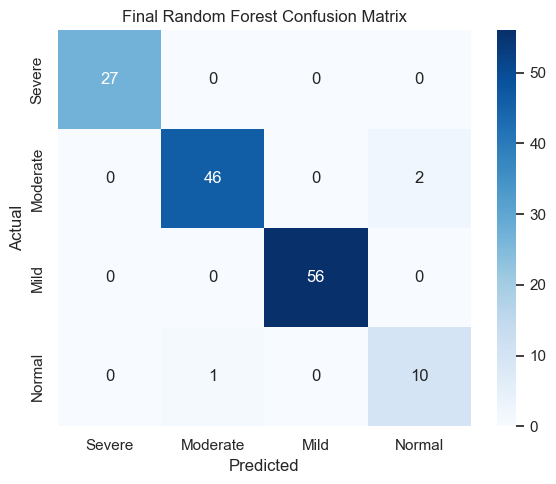


Number of Misclassified Samples: 3

FEATURE IMPORTANCE
     Feature  Importance
0   HB_LEVEL    0.939357
1  Age_Years    0.056078
2   GENDER_1    0.004564


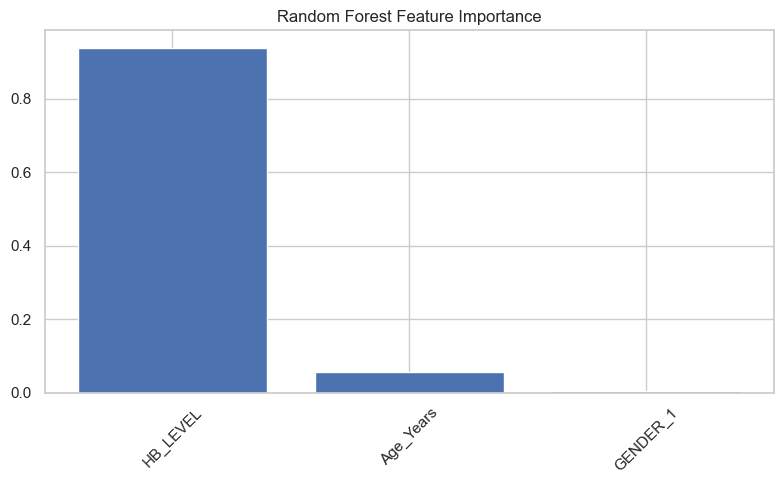


TABULAR MODEL FINALIZED SUCCESSFULLY


In [134]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

# Predictions

y_pred_rf = best_rf.predict(X_test)

# Accuracy & Macro F1
accuracy = accuracy_score(y_test, y_pred_rf)
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
macro_f1 = report_dict['macro avg']['f1-score']

print("\nFINAL RANDOM FOREST PERFORMANCE")
print("Test Accuracy:", accuracy)
print("Test Macro F1:", macro_f1)

# Overfitting Analysis

cv_score = grid_rf.best_score_

print("\nOVERFITTING CHECK")
print("Cross-Validation Macro F1:", cv_score)
print("Test Macro F1:", macro_f1)
print("Difference:", abs(cv_score - macro_f1))

# Classification Report

report_text = classification_report(y_test, y_pred_rf)
print("\nCLASSIFICATION REPORT")
print(report_text)

with open(os.path.join(results_folder, "final_rf_classification_report.txt"), "w") as f:
    f.write(report_text)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title("Final Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "final_rf_confusion_matrix.png"))
plt.show()

# Error Analysis

misclassified_idx = np.where(y_test != y_pred_rf)[0]
print("\nNumber of Misclassified Samples:", len(misclassified_idx))

# Feature Importance

importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFEATURE IMPORTANCE")
print(feat_df)

plt.figure(figsize=(8,5))
plt.bar(feat_df["Feature"], feat_df["Importance"])
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "final_rf_feature_importance.png"))
plt.show()

# Save feature importance CSV
feat_df.to_csv(os.path.join(results_folder, "final_rf_feature_importance.csv"), index=False)

# Save Model

joblib.dump(best_rf, os.path.join(results_folder, "final_random_forest.pkl"))

# Save Summary Table

summary_df = pd.DataFrame([{
    "Model": "Final Random Forest",
    "Test_Accuracy": accuracy,
    "Test_Macro_F1": macro_f1,
    "CV_Macro_F1": cv_score,
    "Overfitting_Gap": abs(cv_score - macro_f1)
}])

summary_df.to_csv(os.path.join(results_folder, "final_rf_summary.csv"), index=False)

print("\nTABULAR MODEL FINALIZED SUCCESSFULLY")


5-FOLD CROSS-VALIDATION: TUNED LOGISTIC REGRESSION


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\Ap


Logistic Regression - Cross-Validation Results:

ACCURACY:
  Test folds:  [0.92105263 0.88596491 0.94736842 0.92920354 0.91150442]
  Mean Test:   0.9190 (+/- 0.0203)
  Mean Train:  0.9291

F1_MACRO:
  Test folds:  [0.90180935 0.84726038 0.93699358 0.89528921 0.88860554]
  Mean Test:   0.8940 (+/- 0.0287)
  Mean Train:  0.9061

PRECISION_MACRO:
  Test folds:  [0.90061519 0.85532285 0.94667832 0.90455378 0.91589027]
  Mean Test:   0.9046 (+/- 0.0295)
  Mean Train:  0.9203

RECALL_MACRO:
  Test folds:  [0.9036132  0.84181929 0.92918193 0.88804945 0.87229853]
  Mean Test:   0.8870 (+/- 0.0294)
  Mean Train:  0.8950

5-FOLD CROSS-VALIDATION: TUNED RANDOM FOREST

Random Forest - Cross-Validation Results:

ACCURACY:
  Test folds:  [0.95614035 0.98245614 0.99122807 0.99115044 0.99115044]
  Mean Test:   0.9824 (+/- 0.0136)
  Mean Train:  1.0000

F1_MACRO:
  Test folds:  [0.90693469 0.97328475 0.98212956 0.98016878 0.98016878]
  Mean Test:   0.9645 (+/- 0.0290)
  Mean Train:  1.0000

PRECISION_

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:51:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:51:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are


XGBoost - Cross-Validation Results:

ACCURACY:
  Test folds:  [0.98245614 0.98245614 0.99122807 0.99115044 1.        ]
  Mean Test:   0.9895 (+/- 0.0066)
  Mean Train:  0.9978

F1_MACRO:
  Test folds:  [0.98218085 0.98206522 0.99093929 0.98016878 1.        ]
  Mean Test:   0.9871 (+/- 0.0075)
  Mean Train:  0.9978

PRECISION_MACRO:
  Test folds:  [0.98958333 0.9893617  0.98863636 0.99375    1.        ]
  Mean Test:   0.9923 (+/- 0.0043)
  Mean Train:  0.9986

RECALL_MACRO:
  Test folds:  [0.97619048 0.97619048 0.99358974 0.96875    1.        ]
  Mean Test:   0.9829 (+/- 0.0118)
  Mean Train:  0.9970

5-FOLD CROSS-VALIDATION SUMMARY
              Model  CV_Accuracy_Mean  CV_Accuracy_Std  CV_F1_Macro_Mean  CV_F1_Macro_Std  Train_Accuracy_Mean  Overfitting_Gap
Logistic Regression          0.919019         0.020301          0.893992         0.028722             0.929139         0.010120
      Random Forest          0.982425         0.013569          0.964537         0.028958             1

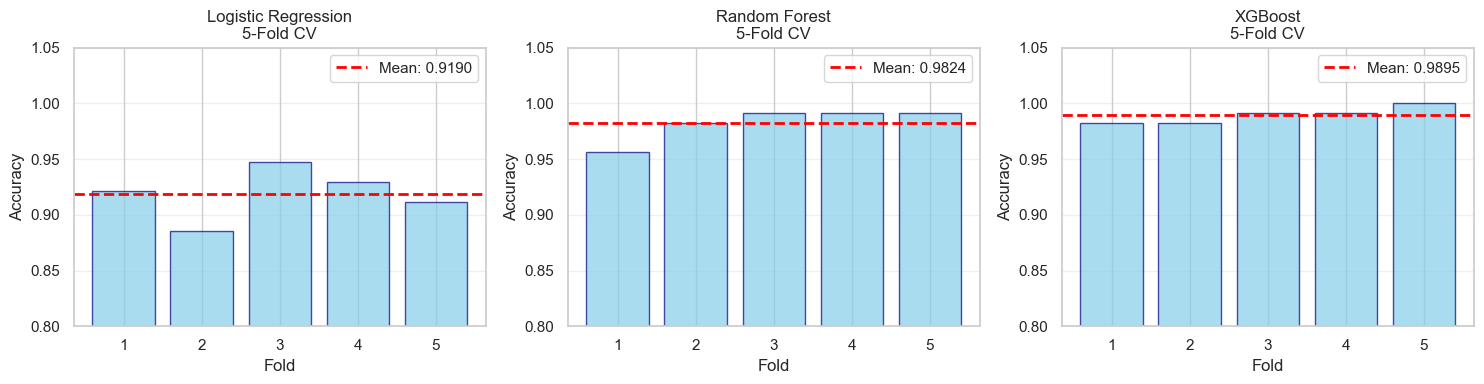

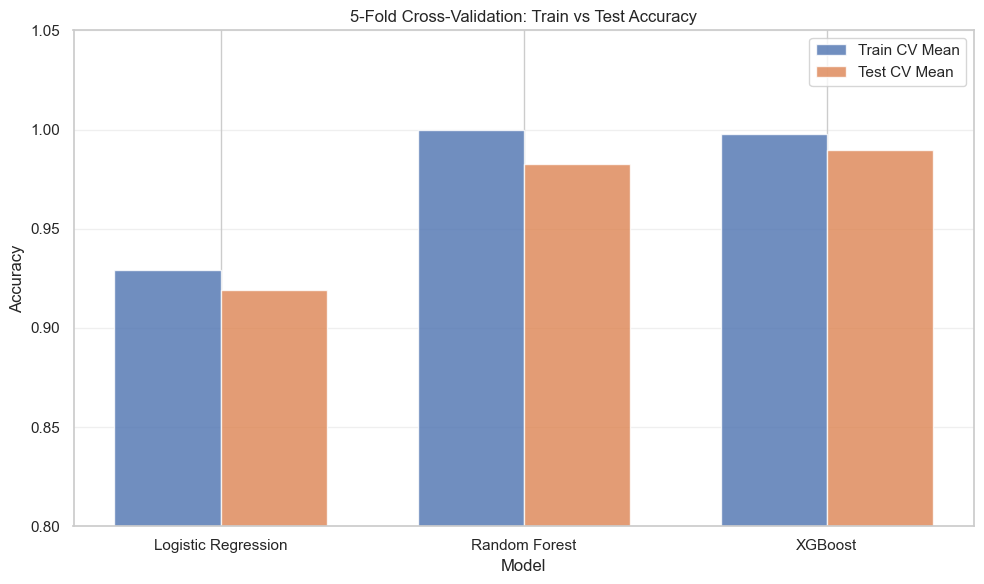


5-Fold Cross-Validation evaluation complete!
Results saved to results/


In [145]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer

# ===== 5-FOLD CROSS-VALIDATION EVALUATION =====

# Initialize 5-fold cross-validation with stratification
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

# Store cross-validation results
cv_results = {}

# ===== CROSS-VALIDATE TUNED LOGISTIC REGRESSION =====
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION: TUNED LOGISTIC REGRESSION")
print("="*60)

cv_lr = cross_validate(best_lr, X_train_scaled, y_train, cv=skf, scoring=scoring, return_train_score=True)
cv_results['Logistic Regression'] = cv_lr

print("\nLogistic Regression - Cross-Validation Results:")
for metric in scoring.keys():
    test_scores = cv_lr[f'test_{metric}']
    train_scores = cv_lr[f'train_{metric}']
    print(f"\n{metric.upper()}:")
    print(f"  Test folds:  {test_scores}")
    print(f"  Mean Test:   {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Mean Train:  {train_scores.mean():.4f}")

# ===== CROSS-VALIDATE TUNED RANDOM FOREST =====
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION: TUNED RANDOM FOREST")
print("="*60)

cv_rf = cross_validate(best_rf, X_train, y_train, cv=skf, scoring=scoring, return_train_score=True)
cv_results['Random Forest'] = cv_rf

print("\nRandom Forest - Cross-Validation Results:")
for metric in scoring.keys():
    test_scores = cv_rf[f'test_{metric}']
    train_scores = cv_rf[f'train_{metric}']
    print(f"\n{metric.upper()}:")
    print(f"  Test folds:  {test_scores}")
    print(f"  Mean Test:   {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Mean Train:  {train_scores.mean():.4f}")

# ===== CROSS-VALIDATE TUNED XGBOOST =====
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION: TUNED XGBOOST")
print("="*60)

cv_xgb = cross_validate(best_xgb, X_train, y_train, cv=skf, scoring=scoring, return_train_score=True)
cv_results['XGBoost'] = cv_xgb

print("\nXGBoost - Cross-Validation Results:")
for metric in scoring.keys():
    test_scores = cv_xgb[f'test_{metric}']
    train_scores = cv_xgb[f'train_{metric}']
    print(f"\n{metric.upper()}:")
    print(f"  Test folds:  {test_scores}")
    print(f"  Mean Test:   {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")
    print(f"  Mean Train:  {train_scores.mean():.4f}")

# ===== SUMMARY COMPARISON TABLE =====
cv_summary = []
for model_name, cv_scores in cv_results.items():
    cv_summary.append({
        'Model': model_name,
        'CV_Accuracy_Mean': cv_scores['test_accuracy'].mean(),
        'CV_Accuracy_Std': cv_scores['test_accuracy'].std(),
        'CV_F1_Macro_Mean': cv_scores['test_f1_macro'].mean(),
        'CV_F1_Macro_Std': cv_scores['test_f1_macro'].std(),
        'Train_Accuracy_Mean': cv_scores['train_accuracy'].mean(),
        'Overfitting_Gap': cv_scores['train_accuracy'].mean() - cv_scores['test_accuracy'].mean()
    })

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df.to_csv(os.path.join(results_folder, "5fold_cv_summary.csv"), index=False)

print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)
print(cv_summary_df.to_string(index=False))

# ===== VISUALIZATION: CV ACCURACY PER FOLD =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
cv_data = [cv_lr, cv_rf, cv_xgb]

for idx, (model_name, cv_scores) in enumerate(zip(models, cv_data)):
    accuracies = cv_scores['test_accuracy']
    folds = np.arange(1, 6)
    
    axes[idx].bar(folds, accuracies, color='skyblue', edgecolor='navy', alpha=0.7)
    axes[idx].axhline(y=accuracies.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {accuracies.mean():.4f}')
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(f'{model_name}\n5-Fold CV')
    axes[idx].set_ylim([0.8, 1.05])
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, "5fold_cv_accuracy_per_fold.png"))
plt.show()

# ===== VISUALIZATION: TRAIN VS TEST ACCURACY =====
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(models))
width = 0.35

train_means = [cv_lr['train_accuracy'].mean(), cv_rf['train_accuracy'].mean(), cv_xgb['train_accuracy'].mean()]
test_means = [cv_lr['test_accuracy'].mean(), cv_rf['test_accuracy'].mean(), cv_xgb['test_accuracy'].mean()]

bars1 = ax.bar(x_pos - width/2, train_means, width, label='Train CV Mean', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, test_means, width, label='Test CV Mean', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation: Train vs Test Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.8, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, "5fold_cv_train_vs_test.png"))
plt.show()

print("\n5-Fold Cross-Validation evaluation complete!")
print(f"Results saved to {results_folder}/")



#  Part 2: Visual Model 

Process eye conjunctiva images 

## Loading Data

Loaded 710 images across 2 classes.
Found 710 files belonging to 2 classes.
Using 568 files for training.
Found 710 files belonging to 2 classes.
Using 142 files for validation.


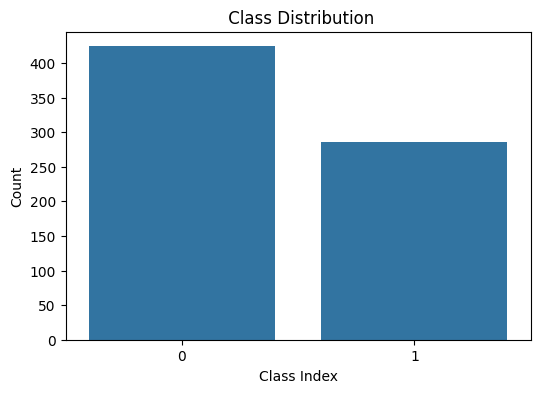

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras.utils import img_to_array, load_img


# --- Paths ---
data_dir = r"C:\Users\USER\Capstone\Bari\data\Images"  
image_classes = ['Anemic', 'Non-Anemic']
img_size = (224, 224)
batch_size = 32
seed = 42
AUTOTUNE = tf.data.AUTOTUNE

# 2. Load images and labels
image_classes = sorted(os.listdir(data_dir))
all_images = []
all_labels = []

for label_idx, class_name in enumerate(image_classes):
    class_dir = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_dir):
        img_path = os.path.join(class_dir, fname)
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img)
        all_images.append(img_array)
        all_labels.append(label_idx)

all_images = np.array(all_images, dtype='float32')
all_labels = np.array(all_labels, dtype='int32')

print(f"Loaded {len(all_images)} images across {len(image_classes)} classes.")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# 2 Check Class Distribution

# 3. Plot class distribution
def plot_class_distribution(labels, title):
    plt.figure(figsize=(6,4))
    sns.countplot(x=labels)
    plt.title(title)
    plt.xlabel("Class Index")
    plt.ylabel("Count")
    plt.show()

plot_class_distribution(all_labels, " Class Distribution")


## Data Manipulation


Total dataset size: 710 images
Image shape: (710, 224, 224, 3)
Label shape: (710,)
Data type: Images=float32, Labels=int32

Missing values in images: 0
Missing values in labels: 0

Image value range: [0.00, 255.00]

Random Image Inspection:


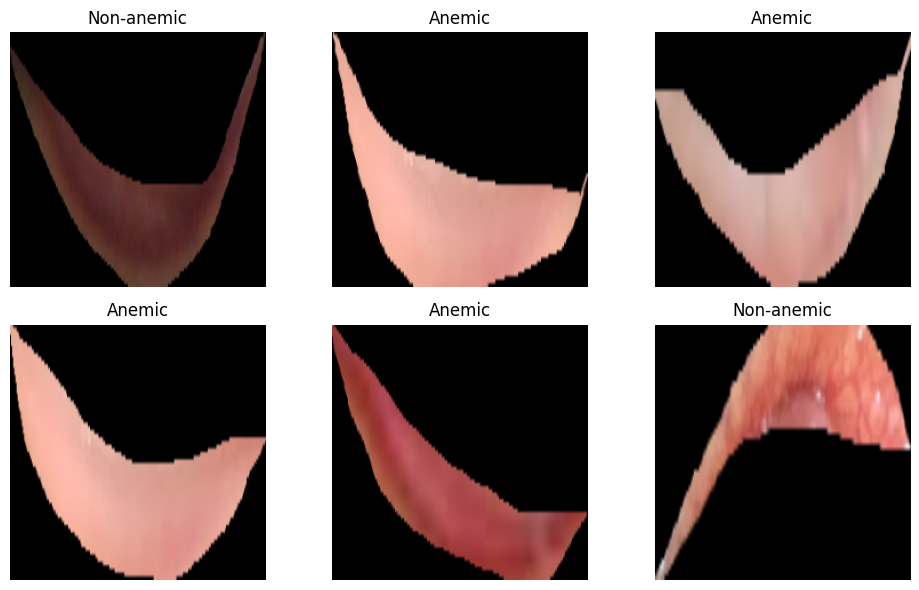


Class distribution:
  Class 0 (Anemic): 424 samples (59.72%)
  Class 1 (Non-anemic): 286 samples (40.28%)
Class imbalance ratio (max/min): 1.48

1. STATISTICAL OUTLIER ANALYSIS:
  Total images: 710
  Mean pixel value outliers: 1 (0.14%)
  Standard deviation outliers: 0 (0.00%)
  Brightness outliers: 1 (0.14%)
  Combined statistical outliers: 1 (0.14%)

2. VISUAL OUTLIER ANALYSIS:
  Potentially corrupted images:
    All black/dark: 0
    All white/bright: 0
    Uniform/low variance: 0

3. CLASS-WISE OUTLIER ANALYSIS:

  Anemic class (424 images):
    Brightness outliers: 0 (0.00%)
    Mean pixel outliers: 0 (0.00%)
    Std deviation outliers: 0 (0.00%)

  Non-anemic class (286 images):
    Brightness outliers: 1 (0.35%)
    Mean pixel outliers: 1 (0.35%)
    Std deviation outliers: 0 (0.00%)

4. OUTLIER VISUALIZATION:


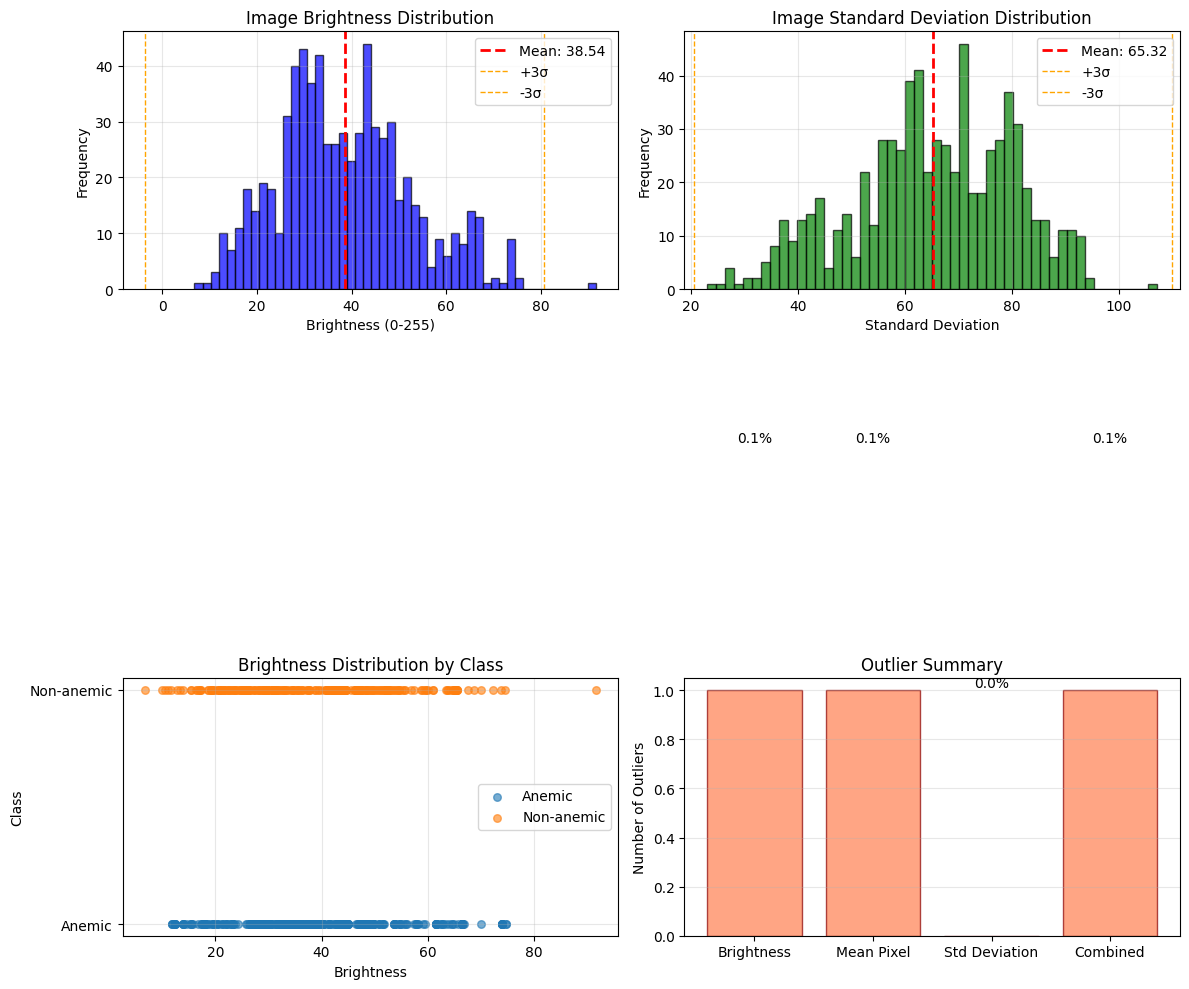


5. OUTLIER REMOVAL ANALYSIS:

Clean dataset size: 709

Class distribution after cleaning:
Anemic: 424 images (59.80%)
Non-anemic: 285 images (40.20%)
  Current dataset: 710 images
  Would remove: 1 outliers (0.14%)
  Remaining: 709 images (99.86%)

  Class distribution after outlier removal:
    Anemic: 424 images (59.80%)
    Non-anemic: 285 images (40.20%)

StratifiedKFold configuration:
  Number of splits: 5
  Shuffle: True
  Random state: 42

Verifying class distribution across folds:

Fold 5:
  Train set - Class 0: 340, Class 1: 228
  Val set   - Class 0: 84, Class 1: 57
Class imbalance ratio (max/min): 1.48


In [23]:
import sklearn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, DenseNet121
from tensorflow.keras import models
from tensorflow.keras import layers
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd 
import random
import matplotlib.pyplot as plt


# Comprehensive data augmentation with multiple strategies
data_augmentation = tf.keras.Sequential([
    # Flip strategies
    layers.RandomFlip("horizontal"),  
    layers.RandomFlip("vertical"),   
    layers.RandomRotation(0.15),      
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.2),           
    layers.RandomContrast(0.2),      
    layers.RandomBrightness(0.2),   
])

# PREPARE DATA FOR 5-FOLD CROSS-VALIDATION
all_images = []
all_labels = []

for batch_images, batch_labels in train_ds:
    all_images.append(batch_images.numpy())
    all_labels.append(batch_labels.numpy())

for batch_images, batch_labels in val_ds:
    all_images.append(batch_images.numpy())
    all_labels.append(batch_labels.numpy())

all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

print(f"\nTotal dataset size: {len(all_images)} images")
print(f"Image shape: {all_images.shape}")
print(f"Label shape: {all_labels.shape}")
print(f"Data type: Images={all_images.dtype}, Labels={all_labels.dtype}")

#  DATA VALIDATION 
print(f"\nMissing values in images: {np.isnan(all_images).sum()}")
print(f"Missing values in labels: {np.isnan(all_labels).sum()}")

# Check image value ranges
print(f"\nImage value range: [{all_images.min():.2f}, {all_images.max():.2f}]")
print("\nRandom Image Inspection:")

indices = random.sample(range(len(all_images)), 6)

plt.figure(figsize=(10,6))

for i, idx in enumerate(indices):
    plt.subplot(2,3,i+1)
    plt.imshow(all_images[idx].astype("uint8"))
    plt.title(image_classes[int(all_labels[idx])])
    plt.axis("off")

plt.tight_layout()
plt.show()
# Check class distribution
class_dist = np.bincount(all_labels.astype(int))
print(f"\nClass distribution:")
for idx, count in enumerate(class_dist):
    percentage = (count / len(all_labels)) * 100
    print(f"  Class {idx} ({image_classes[idx]}): {count} samples ({percentage:.2f}%)")

# Check for imbalance
class_imbalance_ratio = class_dist.max() / class_dist.min()
print(f"Class imbalance ratio (max/min): {class_imbalance_ratio:.2f}")

#  OUTLIER DETECTION AND ANALYSIS 

print("\n1. STATISTICAL OUTLIER ANALYSIS:")

# Calculate image statistics
image_means = []
image_stds = []
image_brightnesses = []

for img in all_images:
    # Convert to grayscale for brightness calculation
    gray_img = np.mean(img, axis=-1)
    image_means.append(np.mean(img))
    image_stds.append(np.std(img))
    image_brightnesses.append(np.mean(gray_img))

image_means = np.array(image_means)
image_stds = np.array(image_stds)
image_brightnesses = np.array(image_brightnesses)

# Calculate z-scores for outlier detection
mean_z_scores = (image_means - np.mean(image_means)) / np.std(image_means)
std_z_scores = (image_stds - np.mean(image_stds)) / np.std(image_stds)
brightness_z_scores = (image_brightnesses - np.mean(image_brightnesses)) / np.std(image_brightnesses)

# Define outlier threshold (z-score > 3 or < -3)
outlier_threshold = 3
mean_outliers = np.abs(mean_z_scores) > outlier_threshold
std_outliers = np.abs(std_z_scores) > outlier_threshold
brightness_outliers = np.abs(brightness_z_scores) > outlier_threshold

print(f"  Total images: {len(all_images)}")
print(f"  Mean pixel value outliers: {mean_outliers.sum()} ({100*mean_outliers.sum()/len(all_images):.2f}%)")
print(f"  Standard deviation outliers: {std_outliers.sum()} ({100*std_outliers.sum()/len(all_images):.2f}%)")
print(f"  Brightness outliers: {brightness_outliers.sum()} ({100*brightness_outliers.sum()/len(all_images):.2f}%)")

# Combined outliers (any statistical outlier)
combined_outliers = mean_outliers | std_outliers | brightness_outliers
print(f"  Combined statistical outliers: {combined_outliers.sum()} ({100*combined_outliers.sum()/len(all_images):.2f}%)")

# 2. Visual Outlier Detection
print("\n2. VISUAL OUTLIER ANALYSIS:")

# Check for corrupted images (all black, all white, or uniform)
black_images = np.all(all_images <= 10, axis=(1,2,3))  # Very dark images
white_images = np.all(all_images >= 245, axis=(1,2,3))  # Very bright images
uniform_images = np.std(all_images, axis=(1,2,3)) < 5  # Very low variance

print(f"  Potentially corrupted images:")
print(f"    All black/dark: {black_images.sum()}")
print(f"    All white/bright: {white_images.sum()}")
print(f"    Uniform/low variance: {uniform_images.sum()}")

# 3. Class-wise Outlier Analysis
print("\n3. CLASS-WISE OUTLIER ANALYSIS:")

for class_idx, class_name in enumerate(image_classes):
    class_mask = all_labels == class_idx
    class_images = all_images[class_mask]

    if len(class_images) > 0:
        class_brightnesses = np.array([np.mean(np.mean(img, axis=-1)) for img in class_images])
        class_means = np.array([np.mean(img) for img in class_images])
        class_stds = np.array([np.std(img) for img in class_images])

        # Outliers in this class
        class_brightness_outliers = np.abs((class_brightnesses - np.mean(class_brightnesses)) / np.std(class_brightnesses)) > outlier_threshold
        class_mean_outliers = np.abs((class_means - np.mean(class_means)) / np.std(class_means)) > outlier_threshold
        class_std_outliers = np.abs((class_stds - np.mean(class_stds)) / np.std(class_stds)) > outlier_threshold

        print(f"\n  {class_name} class ({len(class_images)} images):")
        print(f"    Brightness outliers: {class_brightness_outliers.sum()} ({100*class_brightness_outliers.sum()/len(class_images):.2f}%)")
        print(f"    Mean pixel outliers: {class_mean_outliers.sum()} ({100*class_mean_outliers.sum()/len(class_images):.2f}%)")
        print(f"    Std deviation outliers: {class_std_outliers.sum()} ({100*class_std_outliers.sum()/len(class_images):.2f}%)")

# 4. Outlier Visualization
print("\n4. OUTLIER VISUALIZATION:")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Brightness distribution
axes[0, 0].hist(image_brightnesses, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(np.mean(image_brightnesses), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(image_brightnesses):.2f}')
axes[0, 0].axvline(np.mean(image_brightnesses) + outlier_threshold*np.std(image_brightnesses), color='orange', linestyle='--', linewidth=1, label=f'+{outlier_threshold}σ')
axes[0, 0].axvline(np.mean(image_brightnesses) - outlier_threshold*np.std(image_brightnesses), color='orange', linestyle='--', linewidth=1, label=f'-{outlier_threshold}σ')
axes[0, 0].set_xlabel('Brightness (0-255)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Image Brightness Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Standard deviation distribution
axes[0, 1].hist(image_stds, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(np.mean(image_stds), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(image_stds):.2f}')
axes[0, 1].axvline(np.mean(image_stds) + outlier_threshold*np.std(image_stds), color='orange', linestyle='--', linewidth=1, label=f'+{outlier_threshold}σ')
axes[0, 1].axvline(np.mean(image_stds) - outlier_threshold*np.std(image_stds), color='orange', linestyle='--', linewidth=1, label=f'-{outlier_threshold}σ')
axes[0, 1].set_xlabel('Standard Deviation')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Image Standard Deviation Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Brightness vs Class
for class_idx, class_name in enumerate(image_classes):
    class_mask = all_labels == class_idx
    axes[1, 0].scatter(image_brightnesses[class_mask], [class_idx]*np.sum(class_mask),
                      alpha=0.6, label=class_name, s=30)

axes[1, 0].set_xlabel('Brightness')
axes[1, 0].set_ylabel('Class')
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(image_classes)
axes[1, 0].set_title('Brightness Distribution by Class')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Outlier summary
outlier_types = ['Brightness', 'Mean Pixel', 'Std Deviation', 'Combined']
outlier_counts = [brightness_outliers.sum(), mean_outliers.sum(), std_outliers.sum(), combined_outliers.sum()]
outlier_percentages = [100*count/len(all_images) for count in outlier_counts]

bars = axes[1, 1].bar(outlier_types, outlier_counts, alpha=0.7, color='coral', edgecolor='darkred')
axes[1, 1].set_ylabel('Number of Outliers')
axes[1, 1].set_title('Outlier Summary')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar, percentage in zip(bars, outlier_percentages):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Outlier Removal Decision
print("\n5. OUTLIER REMOVAL ANALYSIS:")
# ===== CREATE CLEAN DATASET =====

clean_images = all_images[~combined_outliers]
clean_labels = all_labels[~combined_outliers]

print("\nClean dataset size:", len(clean_images))

clean_class_dist = np.bincount(clean_labels.astype(int))

print("\nClass distribution after cleaning:")
for idx, class_name in enumerate(image_classes):
    count = clean_class_dist[idx]
    percentage = 100 * count / len(clean_labels)
    print(f"{class_name}: {count} images ({percentage:.2f}%)")
    
# Calculate what would be removed
total_outliers = combined_outliers.sum()
remaining_images = len(all_images) - total_outliers

print(f"  Current dataset: {len(all_images)} images")
print(f"  Would remove: {total_outliers} outliers ({100*total_outliers/len(all_images):.2f}%)")
print(f"  Remaining: {remaining_images} images ({100*remaining_images/len(all_images):.2f}%)")

# Check class distribution after outlier removal
clean_labels = all_labels[~combined_outliers]
clean_class_dist = np.bincount(clean_labels.astype(int))

print(f"\n  Class distribution after outlier removal:")
for idx, (class_name, count) in enumerate(zip(image_classes, clean_class_dist)):
    percentage = 100 * count / len(clean_labels)
    print(f"    {class_name}: {count} images ({percentage:.2f}%)")
    
# ===== CROSS-VALIDATION SETUP ====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nStratifiedKFold configuration:")
print(f"  Number of splits: 5")
print(f"  Shuffle: True")
print(f"  Random state: 42")

# Verify stratification
print(f"\nVerifying class distribution across folds:")
fold_indices = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(clean_images, clean_labels), 1):
    fold_indices.append((train_idx, val_idx))
    train_dist = np.bincount(clean_labels[train_idx].astype(int))
val_dist = np.bincount(clean_labels[val_idx].astype(int))

print(f"\nFold {fold_idx}:")
print(f"  Train set - Class 0: {train_dist[0]}, Class 1: {train_dist[1]}")
print(f"  Val set   - Class 0: {val_dist[0]}, Class 1: {val_dist[1]}")
print(f"Class imbalance ratio (max/min): {class_imbalance_ratio:.2f}")


## Model Training Execution

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# PARAMETERS
img_size = (224, 224)
batch_size = 16
epochs = 25
n_splits = 5
random_state = 42

# DATA AUGMENTATION
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
])

def create_dataset(images, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((clean_images, clean_labels))
    if training:
        dataset = dataset.shuffle(len(images), seed=random_state)
        dataset = dataset.map(lambda x, y: (augmentation(x, training=True), y),
                              num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(lambda x, y: (x / 127.5 - 1, y), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

def create_mobilenet_model(input_shape):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(base.input, outputs)
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# CALLBACKS
def get_callbacks(model_name, fold):
    return [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'best_{model_name}_fold_{fold}.h5', monitor='val_accuracy', save_best_only=True)
    ]

# CROSS-VALIDATION
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
all_fold_scores = []
fold_preds_total = []

for fold, (train_idx, val_idx) in enumerate(skf.split(clean_images, clean_labels), 1):
    X_train, y_train = clean_images[train_idx], clean_labels[train_idx]
    X_val, y_val = clean_images[val_idx], clean_labels[val_idx]
    class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

    print(f"\nTraining MobileNetV2 - Fold {fold}")
    model = create_mobilenet_model(input_shape=img_size + (3,))
    train_ds = create_dataset(X_train, y_train, training=True)
    val_ds = create_dataset(X_val, y_val, training=False)

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs,
                        callbacks=get_callbacks("MobileNetV2", fold),
                        class_weight=class_weights,
                        verbose=1)

val_preds = model.predict(val_ds, steps=len(y_val)//batch_size + 1)

    acc = accuracy_score(y_val, val_preds)
    report = classification_report(y_val, val_preds, output_dict=True)
    all_fold_scores.append({'fold': fold, 'accuracy': acc, 'f1_macro': report['macro avg']['f1-score']})
    fold_preds_total.append(val_preds)

print("MobileNetV2 Cross-Validation Scores:", all_fold_scores)

IndentationError: unexpected indent (3728654787.py, line 80)

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

img_size = (224, 224)
batch_size = 16
n_splits = 5
epochs = 25
random_state = 42

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def create_dataset(images, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        dataset = dataset.shuffle(len(images), seed=random_state)
        dataset = dataset.map(lambda x, y: (augmentation(x, training=True), y),
                              num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

def create_efficientnet_model(input_shape):
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def get_callbacks(model_name, fold):
    return [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'best_{model_name}_fold_{fold}.h5', monitor='val_accuracy', save_best_only=True)
    ]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
fold_indices = list(skf.split(clean_images, clean_labels))
all_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
    X_train, y_train = clean_images[train_idx], clean_labels[train_idx]
    X_val, y_val = clean_images[val_idx], clean_labels[val_idx]

    class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

    print(f"\nTraining EfficientNetB0 - Fold {fold}")
    model = create_efficientnet_model(input_shape=img_size + (3,))
    train_ds = create_dataset(X_train, y_train, training=True)
    val_ds = create_dataset(X_val, y_val, training=False)

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs,
                        callbacks=get_callbacks("EfficientNetB0", fold),
                        class_weight=class_weights,
                        verbose=1)

    val_preds = (model.predict(val_ds) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_val, val_preds)
    report = classification_report(y_val, val_preds, output_dict=True)
    f1_macro = report['macro avg']['f1-score']
    all_fold_scores.append({'fold': fold, 'accuracy': acc, 'f1_macro': f1_macro})

print(all_fold_scores)


Training EfficientNetB0 - Fold 1
Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.5240 - loss: 1.0331

36/36 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.5291 - loss: 1.0226 - val_accuracy: 0.5986 - val_loss: 0.7928 - learning_rate: 1.0000e-04
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5009 - loss: 0.9990 - val_accuracy: 0.5986 - val_loss: 0.7943 - learning_rate: 1.0000e-04
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5220 - loss: 1.0200 - val_accuracy: 0.5986 - val_loss: 0.7969 - learning_rate: 1.0000e-04
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4885 - loss: 1.0167 - val_accuracy: 0.5986 - val_loss: 0.7936 - learning_rate: 1.0000e-04
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.5125 - loss: 0.9862
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5273 - loss: 0.9673 - val_accuracy: 0.5986 - val_loss: 0.7909 - learning_rate: 1.0000e-04
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4885 - loss: 0.9555 - val

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif


Training EfficientNetB0 - Fold 2
Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.5173 - loss: 1.0181

36/36 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5291 - loss: 1.0273 - val_accuracy: 0.5986 - val_loss: 0.8056 - learning_rate: 1.0000e-04
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5026 - loss: 0.9980 - val_accuracy: 0.5986 - val_loss: 0.8026 - learning_rate: 1.0000e-04
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.4903 - loss: 1.0327 - val_accuracy: 0.5986 - val_loss: 0.7980 - learning_rate: 1.0000e-04
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4674 - loss: 1.0333 - val_accuracy: 0.4014 - val_loss: 0.8154 - learning_rate: 1.0000e-04
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.4729 - loss: 1.0758
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4727 - loss: 1.0469 - val_accuracy: 0.5986 - val_loss: 0.8071 - learning_rate: 1.0000e-04
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4956 - loss: 0.9677 - val

...

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif


Training EfficientNetB0 - Fold 5
Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.4659 - loss: 1.0518

36/36 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4930 - loss: 1.0390 - val_accuracy: 0.5957 - val_loss: 0.8092 - learning_rate: 1.0000e-04
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5018 - loss: 1.0512 - val_accuracy: 0.4043 - val_loss: 0.8178 - learning_rate: 1.0000e-04
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5123 - loss: 0.9716 - val_accuracy: 0.4043 - val_loss: 0.8354 - learning_rate: 1.0000e-04
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4947 - loss: 0.9647 - val_accuracy: 0.4043 - val_loss: 0.8256 - learning_rate: 1.0000e-04
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4942 - loss: 0.9353
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4859 - loss: 0.9570 - val_accuracy: 0.4043 - val_loss: 0.8535 - learning_rate: 1.0000e-04
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5018 - loss: 0.9379 - val_ac

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

[{'fold': 1, 'accuracy': 0.5985915492957746, 'f1_macro': 0.3744493392070485}, {'fold': 2, 'accuracy': 0.5985915492957746, 'f1_macro': 0.3744493392070485}, {'fold': 3, 'accuracy': 0.5985915492957746, 'f1_macro': 0.3744493392070485}, {'fold': 4, 'accuracy': 0.5985915492957746, 'f1_macro': 0.3744493392070485}, {'fold': 5, 'accuracy': 0.5957446808510638, 'f1_macro': 0.37333333333333335}]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

img_size = (224, 224)
batch_size = 16
n_splits = 5
epochs = 25
random_state = 42

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def create_dataset(images, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        dataset = dataset.shuffle(len(images), seed=random_state)
        dataset = dataset.map(lambda x, y: (augmentation(x, training=True), y),
                              num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

def create_densenet_model(input_shape):
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def get_callbacks(model_name, fold):
    return [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'best_{model_name}_fold_{fold}.h5', monitor='val_accuracy', save_best_only=True)
    ]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
fold_indices = list(skf.split(clean_images, clean_labels))
all_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
    X_train, y_train = clean_images[train_idx], clean_labels[train_idx]
    X_val, y_val = clean_images[val_idx], clean_labels[val_idx]

    class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

    print(f"\nTraining DenseNet121 - Fold {fold}")
    model = create_densenet_model(input_shape=img_size + (3,))
    train_ds = create_dataset(X_train, y_train, training=True)
    val_ds = create_dataset(X_val, y_val, training=False)

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs,
                        callbacks=get_callbacks("DenseNet121", fold),
                        class_weight=class_weights,
                        verbose=1)

    val_preds = (model.predict(val_ds) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_val, val_preds)
    report = classification_report(y_val, val_preds, output_dict=True)
    f1_macro = report['macro avg']['f1-score']
    all_fold_scores.append({'fold': fold, 'accuracy': acc, 'f1_macro': f1_macro})

print(all_fold_scores)

9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step 
Accuracy: 0.5985915492957746
Precision: 0.0
Recall: 0.0
F1: 0.0


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


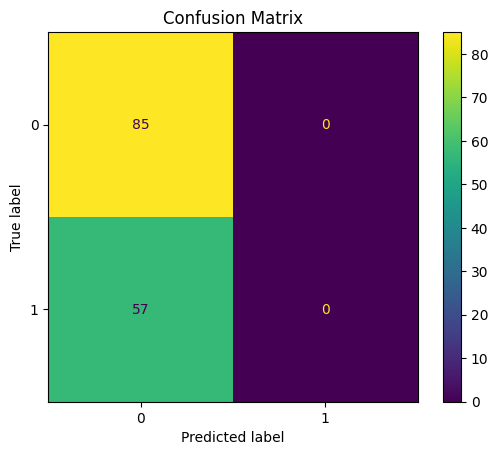

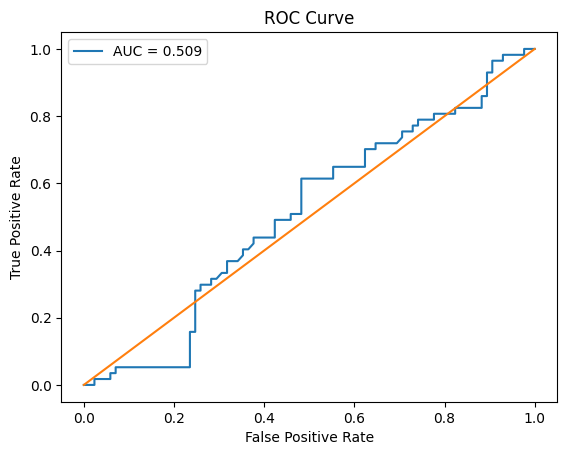

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import tensorflow as tf
import numpy as np

# ===== FUNCTION: Plot Confusion Matrix =====
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=image_classes, yticklabels=image_classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# ===== FUNCTION: Plot ROC Curve =====
def plot_roc(y_true, y_scores, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    return roc_auc

# ===== FUNCTION: Grad-CAM =====
def generate_gradcam(model, img_tensor, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap)+1e-8)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    import cv2
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    plt.figure(figsize=(4,4))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# ===== EVALUATE MODELS AND ENSEMBLE =====
for model_name in models_to_train:
    y_true_all = []
    y_pred_all = []
    y_scores_all = []

    print(f"\n=== Evaluation for {model_name} ===")
    for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
        X_val, y_val = clean_images[val_idx], clean_labels[val_idx]
        val_ds = create_dataset(X_val, y_val, training=False)

        model = models_to_train[model_name](input_shape=img_size + (3,))
        model.load_weights(f'best_{model_name}_fold_{fold}.h5')

        preds_proba = model.predict(val_ds).flatten()
        preds_class = (preds_proba > 0.5).astype(int)

        y_true_all.extend(y_val)
        y_pred_all.extend(preds_class)
        y_scores_all.extend(preds_proba)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_scores_all = np.array(y_scores_all)

    # Metrics
    acc = accuracy_score(y_true_all, y_pred_all)
    precision = precision_score(y_true_all, y_pred_all)
    recall = recall_score(y_true_all, y_pred_all)
    f1 = f1_score(y_true_all, y_pred_all)
    roc_auc = plot_roc(y_true_all, y_scores_all, title=f"{model_name} ROC Curve")

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")
    plot_confusion(y_true_all, y_pred_all, title=f"{model_name} Confusion Matrix")

    # Grad-CAM Example on first validation image
    img_tensor = tf.expand_dims(X_val[0], axis=0)
    last_conv_layer_name = model.layers[-5].name  # adjust depending on model
    heatmap = generate_gradcam(model, img_tensor, last_conv_layer_name)
    display_gradcam((X_val[0]*255).astype(np.uint8), heatmap)

In [ ]:
# ===== FINE-TUNED MODELS WITH TTA & ENSEMBLE =====
tta_steps = 5  # number of augmented predictions per image
for model_name, model_func in models_to_train.items():
    print(f"\n=== Fine-Tuning + TTA for {model_name} ===")
    y_true_total = []
    y_pred_total = []
    y_score_total = []

    for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
        X_train, y_train = clean_images[train_idx], clean_labels[train_idx]
        X_val, y_val = clean_images[val_idx], clean_labels[val_idx]

        # ---- CLASS WEIGHTS ----
        class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

        # ---- MODEL ----
        model = model_func(input_shape=img_size+(3,))
        model.trainable = True  # allow fine-tuning
        # Fine-tune last 20% of layers
        total_layers = len(model.layers)
        for layer in model.layers[:int(total_layers*0.8)]:
            layer.trainable = False

        model.compile(optimizer=Adam(1e-5),  # lower LR for fine-tuning
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        train_ds = create_dataset(X_train, y_train, training=True)
        val_ds = create_dataset(X_val, y_val, training=False)

        history = model.fit(train_ds, validation_data=val_ds,
                            epochs=15,
                            callbacks=get_callbacks(model_name, fold),
                            class_weight=class_weights,
                            verbose=1)

        # ---- TTA PREDICTION ----
        preds_tta = []
        for _ in range(tta_steps):
            val_ds_aug = create_dataset(X_val, y_val, training=True)  # apply augmentation
            preds_tta.append(model.predict(val_ds_aug).flatten())
        preds_avg = np.mean(preds_tta, axis=0)
        preds_class = (preds_avg > 0.5).astype(int)

        y_true_total.extend(y_val)
        y_pred_total.extend(preds_class)
        y_score_total.extend(preds_avg)

    # ---- METRICS & PLOTS ----
    y_true_total = np.array(y_true_total)
    y_pred_total = np.array(y_pred_total)
    y_score_total = np.array(y_score_total)

    acc = accuracy_score(y_true_total, y_pred_total)
    precision = precision_score(y_true_total, y_pred_total)
    recall = recall_score(y_true_total, y_pred_total)
    f1 = f1_score(y_true_total, y_pred_total)
    roc_auc = plot_roc(y_true_total, y_score_total, title=f"{model_name} ROC Curve (TTA + Fine-Tune)")
    plot_confusion(y_true_total, y_pred_total, title=f"{model_name} Confusion Matrix (TTA + Fine-Tune)")

    print(f"{model_name} - Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")

# ===== ENSEMBLE SOFT VOTING ACROSS MODELS =====
print("\n=== Ensemble Soft Voting Across Models ===")
ensemble_preds = []
y_true_total = []

for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
    X_val, y_val = clean_images[val_idx], clean_labels[val_idx]
    y_true_total.extend(y_val)

    fold_preds = []
    for model_name, model_func in models_to_train.items():
        model = model_func(input_shape=img_size+(3,))
        model.load_weights(f'best_{model_name}_fold_{fold}.h5')
        preds_tta = []
        for _ in range(tta_steps):
            val_ds_aug = create_dataset(X_val, y_val, training=True)
            preds_tta.append(model.predict(val_ds_aug).flatten())
        preds_avg = np.mean(preds_tta, axis=0)
        fold_preds.append(preds_avg)
    # soft-voting ensemble
    ensemble_avg = np.mean(fold_preds, axis=0)
    ensemble_preds.extend((ensemble_avg > 0.5).astype(int))

y_true_total = np.array(y_true_total)
ensemble_preds = np.array(ensemble_preds)

acc = accuracy_score(y_true_total, ensemble_preds)
precision = precision_score(y_true_total, ensemble_preds)
recall = recall_score(y_true_total, ensemble_preds)
f1 = f1_score(y_true_total, ensemble_preds)
roc_auc = plot_roc(y_true_total, ensemble_preds, title="Ensemble ROC Curve")
plot_confusion(y_true_total, ensemble_preds, title="Ensemble Confusion Matrix")

print(f"Ensemble - Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")

NameError: name 'models_to_train' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

mobilenet_prob = mobilenet_model.predict(val_ds).flatten()
efficientnet_prob = efficientnet_model.predict(val_ds).flatten()
densenet_prob = densenet_model.predict(val_ds).flatten()

ensemble_prob = (mobilenet_prob + efficientnet_prob + densenet_prob) / 3

ensemble_pred = (ensemble_prob > 0.5).astype(int)

accuracy = accuracy_score(y_val, ensemble_pred)

print("Ensemble Accuracy:", accuracy)

print(classification_report(y_val, ensemble_pred))

FULL FINE-TUNING &EVALUATION BLOCK

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.2212 - loss: 1.8841 - val_accuracy: 0.2069 - val_loss: 1.4636
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3097 - loss: 1.5623 - val_accuracy: 0.2759 - val_loss: 1.2987
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3982 - loss: 1.3456 - val_accuracy: 0.3448 - val_loss: 1.2188
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4071 - loss: 1.2818 - val_accuracy: 0.3448 - val_loss: 1.1828
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3805 - loss: 1.3243 - val_accuracy: 0.4483 - val_loss: 1.1620
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4425 - loss: 1.2584 - val_accuracy: 0.3448 - val_loss: 1.1961
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3717 - loss: 1.2775 - val_accuracy: 0.2414 - val_loss: 1.2391
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3982 - loss: 1.2504 - va

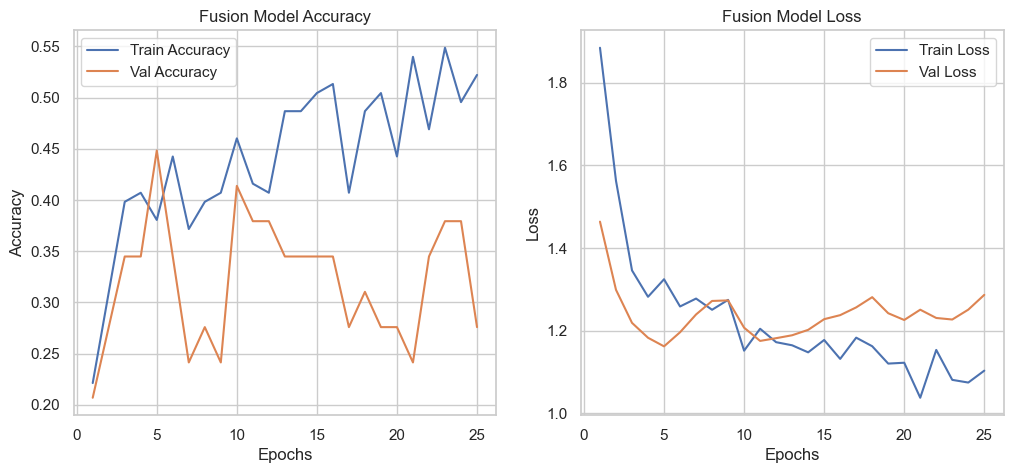

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Fusion Model Accuracy: 0.5845

Classification Report:
               precision    recall  f1-score   support

      Severe       0.83      0.19      0.30        27
    Moderate       0.52      0.81      0.63        48
        Mild       0.63      0.68      0.66        56
      Normal       1.00      0.09      0.17        11

    accuracy                           0.58       142
   macro avg       0.75      0.44      0.44       142
weighted avg       0.66      0.58      0.54       142



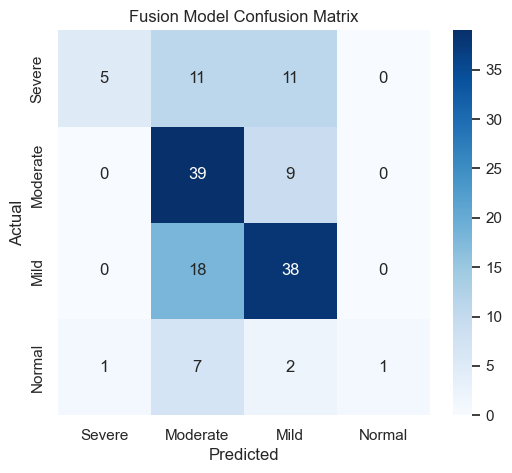


Sample 1:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Symptoms: ['Fatigue', 'Paleness', 'Shortness of breath on exertion', 'Weakness']
Nutrition: ['Beans, lentils, spinach', 'Vitamin C foods: citrus, peppers', 'B12: eggs, dairy, fish', 'Folate: broccoli, leafy greens']
Exercise: ['Light to moderate activity okay', 'Avoid high-intensity workouts']

Sample 2:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Symptoms: ['Fatigue', 'Paleness', 'Shortness of breath on exertion', 'Weakness']
Nutrition: ['Beans, lentils, spinach', 'Vitamin C foods: citrus, peppers', 'B12: eggs, dairy, fish', 'Folate: broccoli, leafy greens']
Exercise: ['Light to moderate activity okay', 'Avoid high-intensity workouts']

Sample 3:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Sympt

In [148]:
# TABULAR & IMAGE FUSION MODEL WITH NUTRITIONAL PLAN

import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 0. Define anemia guidelines

anemia_guidelines = {
    0: {  # Severe
        "severity": "Severe Anemia (<7 g/dL)",
        "medical_advice": "Immediate medical consultation required.",
        "symptoms": ["Extreme fatigue", "Shortness of breath", "Dizziness", "Pale skin", "Rapid heartbeat"],
        "nutrition": ["Red meat, liver, beans, lentils", "Vitamin C foods: oranges, peppers", "Folate: spinach, kale", "B12: eggs, dairy"],
        "exercise": ["Avoid strenuous exercise until cleared", "Light walking/stretching under supervision"]
    },
    1: {  # Moderate
        "severity": "Moderate Anemia (7–9.9 g/dL)",
        "medical_advice": "Consult doctor for iron therapy if needed.",
        "symptoms": ["Fatigue", "Paleness", "Shortness of breath on exertion", "Weakness"],
        "nutrition": ["Beans, lentils, spinach", "Vitamin C foods: citrus, peppers", "B12: eggs, dairy, fish", "Folate: broccoli, leafy greens"],
        "exercise": ["Light to moderate activity okay", "Avoid high-intensity workouts"]
    },
    2: {  # Mild
        "severity": "Mild Anemia (10–11.9 g/dL)",
        "medical_advice": "Maintain balanced diet, regular checkups recommended.",
        "symptoms": ["Tiredness", "Slight paleness", "Occasional dizziness"],
        "nutrition": ["Balanced diet with iron-rich foods", "Vitamin C to aid absorption", "Moderate red meat or plant-based iron"],
        "exercise": ["Normal activity okay", "Include regular aerobic activity"]
    },
    3: {  # Non-anemic
        "severity": "Non-Anemic (≥12 g/dL)",
        "medical_advice": "No treatment required.",
        "symptoms": [],
        "nutrition": ["Balanced diet with varied nutrients", "Iron from diet as needed"],
        "exercise": ["Regular exercise recommended"]
    }
}

# Define classes for fusion (severity levels)
classes = ['Severe', 'Moderate', 'Mild', 'Normal']

# 1. Prepare tabular embeddings (Random Forest predictions/probabilities)

tabular_probs = best_rf.predict_proba(X_test)  # shape: (num_samples, num_classes)


# 2. Extract image embeddings from fine-tuned MobileNetV2

feature_extractor = models.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output   # GlobalAveragePooling layer
)
image_embeddings = feature_extractor.predict(val_images)  # shape: (num_samples, embedding_dim)

# 3. Concatenate tabular + image features

fusion_input = np.concatenate([image_embeddings, tabular_probs], axis=1)
fusion_labels = y_test  # same as test labels

# 4. Build fusion neural network

input_dim = fusion_input.shape[1]
fusion_input_layer = Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(fusion_input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
fusion_output = layers.Dense(len(classes), activation='softmax')(x)

fusion_model = models.Model(fusion_input_layer, fusion_output)
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train fusion model

history_fusion = fusion_model.fit(
    fusion_input, fusion_labels,
    validation_split=0.2,
    epochs=25,
    batch_size=16
)

# 6. Plot fusion training curves

acc = history_fusion.history['accuracy']
val_acc = history_fusion.history['val_accuracy']
loss = history_fusion.history['loss']
val_loss = history_fusion.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("Fusion Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Fusion Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 7. Evaluate fusion model

fusion_preds = np.argmax(fusion_model.predict(fusion_input), axis=1)

print(f"\nFusion Model Accuracy: {accuracy_score(fusion_labels, fusion_preds):.4f}")
print("\nClassification Report:\n", classification_report(fusion_labels, fusion_preds, target_names=classes))

cm = confusion_matrix(fusion_labels, fusion_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fusion Model Confusion Matrix")
plt.show()

# 8. Map predictions to nutritional plan + exercise + symptoms

results = []
for pred in fusion_preds:
    plan = anemia_guidelines[pred]
    results.append({
        "Predicted_Class": classes[pred],
        "Severity": plan["severity"],
        "Medical_Advice": plan["medical_advice"],
        "Symptoms": plan["symptoms"],
        "Nutrition": plan["nutrition"],
        "Exercise": plan["exercise"]
    })

# Example: print first 3 results
for i, r in enumerate(results[:3]):
    print(f"\nSample {i+1}:")
    for k, v in r.items():
        print(f"{k}: {v}")

# 9. Save fusion model

fusion_model.save('fusion_model_tabular_visual_with_plan.h5')
print("Fusion model with nutritional plan saved successfully!")

## 3. Fusion Layer

5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.3009 - loss: 1.5500 - val_accuracy: 0.1724 - val_loss: 1.3558
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3894 - loss: 1.3636 - val_accuracy: 0.1724 - val_loss: 1.3458
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2920 - loss: 1.3873 - val_accuracy: 0.1034 - val_loss: 1.3461
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3628 - loss: 1.3198 - val_accuracy: 0.1724 - val_loss: 1.3166
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3982 - loss: 1.3181 - val_accuracy: 0.1034 - val_loss: 1.3259
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3717 - loss: 1.3050 - val_accuracy: 0.2069 - val_loss: 1.3172
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3894 - loss: 1.2854 - val_accuracy: 0.2759 - val_loss: 1.2866
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4779 - loss: 1.2062 - va

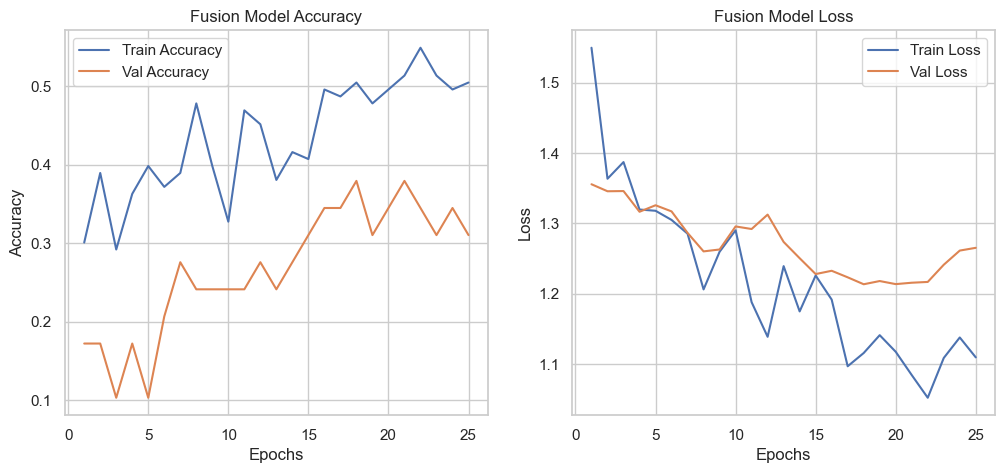

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Fusion Model Accuracy: 0.5845

Classification Report:
               precision    recall  f1-score   support

      Severe       0.83      0.19      0.30        27
    Moderate       0.54      0.73      0.62        48
        Mild       0.60      0.73      0.66        56
      Normal       0.67      0.18      0.29        11

    accuracy                           0.58       142
   macro avg       0.66      0.46      0.47       142
weighted avg       0.63      0.58      0.55       142



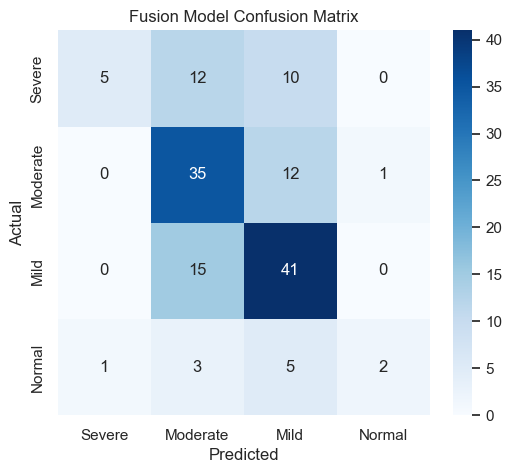

Fusion model saved successfully!


In [131]:
# TABULAR & IMAGE FUSION MODEL


import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare tabular embeddings (Random Forest predictions/probabilities) ---
tabular_probs = best_rf.predict_proba(X_test)

# --- 2. Extract image embeddings from fine-tuned MobileNetV2 ---
feature_extractor = models.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output   # GlobalAveragePooling layer
)

image_embeddings = feature_extractor.predict(val_images)

# --- 3. Concatenate tabular + image features ---
fusion_input = np.concatenate([image_embeddings, tabular_probs], axis=1)
fusion_labels = y_test  # same as test labels

# --- 4. Build fusion neural network ---
input_dim = fusion_input.shape[1]
fusion_input_layer = Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(fusion_input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
fusion_output = layers.Dense(len(classes), activation='softmax')(x)

fusion_model = models.Model(fusion_input_layer, fusion_output)
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Train fusion model ---
history_fusion = fusion_model.fit(
    fusion_input, fusion_labels,
    validation_split=0.2,
    epochs=25,
    batch_size=16
)

# --- 6. Plot fusion training curves ---
acc = history_fusion.history['accuracy']
val_acc = history_fusion.history['val_accuracy']
loss = history_fusion.history['loss']
val_loss = history_fusion.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("Fusion Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Fusion Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- 7. Evaluate fusion model ---
fusion_preds = np.argmax(fusion_model.predict(fusion_input), axis=1)

print(f"\nFusion Model Accuracy: {accuracy_score(fusion_labels, fusion_preds):.4f}")
print("\nClassification Report:\n", classification_report(fusion_labels, fusion_preds, target_names=classes))

cm = confusion_matrix(fusion_labels, fusion_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fusion Model Confusion Matrix")
plt.show()

# --- 8. Save fusion model ---
fusion_model.save('fusion_model_tabular_visual.h5')
print("Fusion model saved successfully!")